In [1]:
# Set seed for reproducibility from top of file
set.seed(2026)

# Load libraries

In [2]:
# install.packages(c("caret", "tidyverse", "moments", "survival", "leaps", "glmnet"))

library(tidyverse)
library(moments)
library(caret)
library(survival)
library(leaps)
library(glmnet)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   4.0.0     ✔ tibble    3.3.0
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
✔ purrr     1.1.0     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Warning message:
"package 'moments' was built under R version 4.5.2"
Warning message:
"package 'caret' was built under R version 4.5.2"
Loading required package: lattice


Attaching package: 'caret'


The following object is masked from 'package:purrr':

    lift


Warning message:
"package 'survival' was built under R version 4.5.2"

Attaching package: 'survival'


The following object is masked from 'package:caret':

    cluster


Warning message:
"package 'leaps' was b

# Load data / Start EDA

In [1]:
raw_df <- read.csv("METABRIC_RNA_Mutation.csv")

# Explore data
head(raw_df)

cat("Number of rows:", nrow(raw_df), "\n",
    "Number of columns:", ncol(raw_df), "\n")

colnames(raw_df)

,patient_id,age_at_diagnosis,type_of_breast_surgery,cancer_type,cancer_type_detailed,cellularity,chemotherapy,pam50_._claudin.low_subtype,cohort,er_status_measured_by_ihc,⋯,mtap_mut,ppp2cb_mut,smarcd1_mut,nras_mut,ndfip1_mut,hras_mut,prps2_mut,smarcb1_mut,stmn2_mut,siah1_mut
,<int>,<dbl>,<chr>,<chr>,<chr>,<chr>,<int>,<chr>,<dbl>,<chr>,⋯,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
1,0,75.65,MASTECTOMY,Breast Cancer,Breast Invasive Ductal Carcinoma,,0,claudin-low,1,Positve,⋯,0,0,0,0,0,0,0,0,0,0
2,2,43.19,BREAST CONSERVING,Breast Cancer,Breast Invasive Ductal Carcinoma,High,0,LumA,1,Positve,⋯,0,0,0,0,0,0,0,0,0,0
3,5,48.87,MASTECTOMY,Breast Cancer,Breast Invasive Ductal Carcinoma,High,1,LumB,1,Positve,⋯,0,0,0,0,0,0,0,0,0,0
4,6,47.68,MASTECTOMY,Breast Cancer,Breast Mixed Ductal and Lobular Carcinoma,Moderate,1,LumB,1,Positve,⋯,0,0,0,0,0,0,0,0,0,0
5,8,76.97,MASTECTOMY,Breast Cancer,Breast Mixed Ductal and Lobular Carcinoma,High,1,LumB,1,Positve,⋯,0,0,0,0,0,0,0,0,0,0
6,10,78.77,MASTECTOMY,Breast Cancer,Breast Invasive Ductal Carcinoma,Moderate,0,LumB,1,Positve,⋯,0,0,0,0,0,0,0,0,0,0


Number of rows: 1904 
 Number of columns: 693 


[1] "patient_id"                     "age_at_diagnosis"              
  [3] "type_of_breast_surgery"         "cancer_type"                   
  [5] "cancer_type_detailed"           "cellularity"                   
  [7] "chemotherapy"                   "pam50_._claudin.low_subtype"   
  [9] "cohort"                         "er_status_measured_by_ihc"     
 [11] "er_status"                      "neoplasm_histologic_grade"     
 [13] "her2_status_measured_by_snp6"   "her2_status"                   
 [15] "tumor_other_histologic_subtype" "hormone_therapy"               
 [17] "inferred_menopausal_state"      "integrative_cluster"           
 [19] "primary_tumor_laterality"       "lymph_nodes_examined_positive" 
 [21] "mutation_count"                 "nottingham_prognostic_index"   
 [23] "oncotree_code"                  "overall_survival_months"       
 [25] "overall_survival"               "pr_status"                     
 [27] "radio_therapy"                  "X3.gene_classifier_subtype"    
 [29] "tumor_size"                     "tumor_stage"                   
 [31] "death_from_cancer"              "brca1"                         
 [33] "brca2"                          "palb2"                         
 [35] "pten"                           "tp53"                          
 [37] "atm"                            "cdh1"                          
 [39] "chek2"                          "nbn"                           
 [41] "nf1"                            "stk11"                         
 [43] "bard1"                          "mlh1"                          
 [45] "msh2"                           "msh6"                          
 [47] "pms2"                           "epcam"                         
 [49] "rad51c"                         "rad51d"                        
 [51] "rad50"                          "rb1"                           
 [53] "rbl1"                           "rbl2"                          
 [55] "ccna1"                          "ccnb1"                         
 [57] "cdk1"                           "ccne1"                         
 [59] "cdk2"                           "cdc25a"                        
 [61] "ccnd1"                          "cdk4"                          
 [63] "cdk6"                           "ccnd2"                         
 [65] "cdkn2a"                         "cdkn2b"                        
 [67] "myc"                            "cdkn1a"                        
 [69] "cdkn1b"                         "e2f1"                          
 [71] "e2f2"                           "e2f3"                          
 [73] "e2f4"                           "e2f5"                          
 [75] "e2f6"                           "e2f7"                          
 [77] "e2f8"                           "src"                           
 [79] "jak1"                           "jak2"                          
 [81] "stat1"                          "stat2"                         
 [83] "stat3"                          "stat5a"                        
 [85] "stat5b"                         "mdm2"                          
 [87] "tp53bp1"                        "adam10"                        
 [89] "adam17"                         "aph1a"                         
 [91] "aph1b"                          "arrdc1"                        
 [93] "cir1"                           "ctbp1"                         
 [95] "ctbp2"                          "cul1"                          
 [97] "dll1"                           "dll3"                          
 [99] "dll4"                           "dtx1"                          
[101] "dtx2"                           "dtx3"                          
[103] "dtx4"                           "ep300"                         
[105] "fbxw7"                          "hdac1"                         
[107] "hdac2"                          "hes1"                          
[109] "hes5"                           "heyl"                          
[111] "itch"                           "ja

In [7]:
# Global missingness check
miss_df <- data.frame(
  missing_count = colSums(is.na(raw_df)),
  missing_pct = round(colMeans(is.na(raw_df)) * 100, 3)
)

miss_df <- miss_df[miss_df$missing_count > 0, ]
miss_df

,missing_count,missing_pct
,<dbl>,<dbl>
neoplasm_histologic_grade,72,3.782
mutation_count,45,2.363
tumor_size,20,1.050
tumor_stage,501,26.313


In [8]:
# Mean time to event by tumor stage (ignoring missing)
aggregate(
  raw_df$overall_survival_months ~ raw_df$tumor_stage,
  FUN = median,
  na.rm = TRUE
)

raw_df$tumor_stage,raw_df$overall_survival_months
<dbl>,<dbl>
0,95.30000
1,152.06667
2,108.33333
3,54.10000
4,48.53333


[1] 0.384

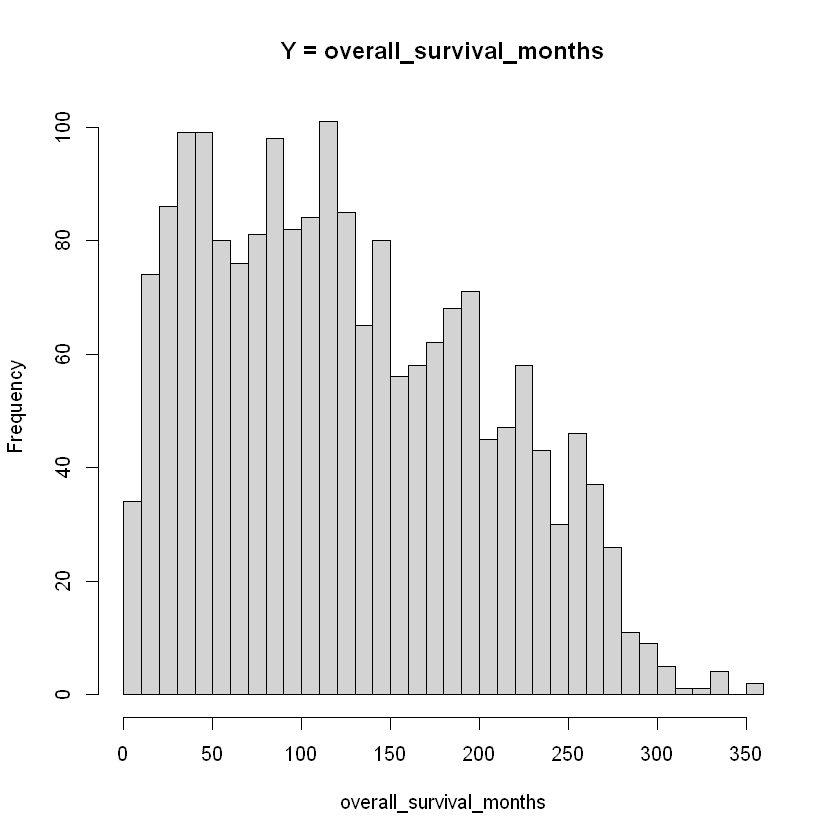

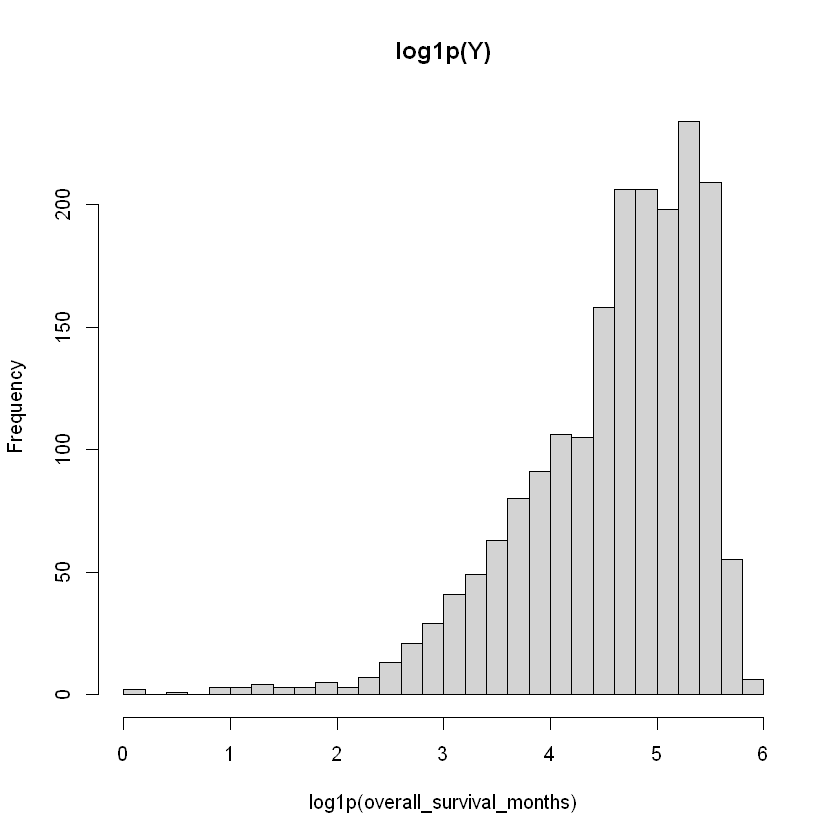

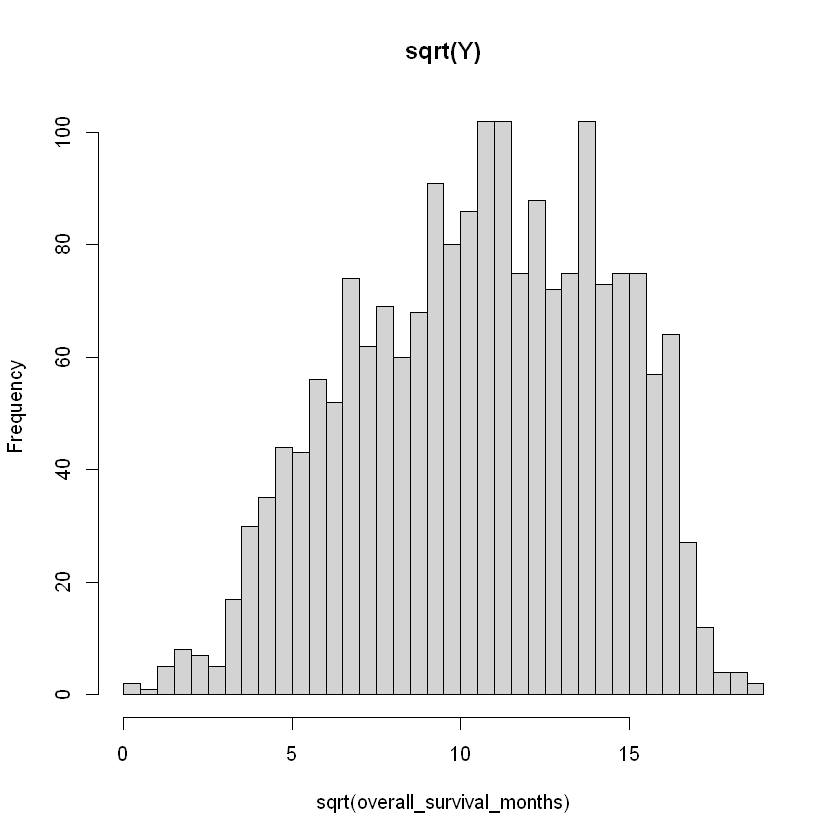

In [9]:
# Check target skew
round(skewness(raw_df$overall_survival_months, na.rm = TRUE), 3)

# Raw distribution of `overall_survival_months`
hist(raw_df$overall_survival_months,
     breaks = 40,
     main = "Y = overall_survival_months",
     xlab = "overall_survival_months")

# Log transformation
hist(log1p(raw_df$overall_survival_months),
     breaks = 40,
     main = "log1p(Y)",
     xlab = "log1p(overall_survival_months)")

# Square root transformation
hist(sqrt(raw_df$overall_survival_months),
     breaks = 40,
     main = "sqrt(Y)",
     xlab = "sqrt(overall_survival_months)")

#### Distribution note
- Cox doesn't assume normality/parametric form. So distribution transformation won't benefit model.
- Instead: 
    - Event balance (overall_survival)
    - Temporal order (overall_survival_months)
    - Predictor variance
    - Highly correlated predictors

In [10]:
# Event distribution (alive or dead) [target variable to combine with time variable for survival analysis]
table(raw_df$overall_survival, useNA = "ifany")


   0    1 
1103  801 

# **Split high-dimensional dataset for easier pre-process**

In [11]:
clinical_vars <- raw_df %>%
  select(age_at_diagnosis:(brca1)) %>% 
  select(-brca1)

gene_vars <- raw_df %>%
  select(brca1:pik3ca_mut) %>%
  select(-pik3ca_mut)

mutation_vars <- raw_df %>%
  select(ends_with("_mut"))

In [12]:
head(clinical_vars)
head(gene_vars)
head(mutation_vars)

,age_at_diagnosis,type_of_breast_surgery,cancer_type,cancer_type_detailed,cellularity,chemotherapy,pam50_._claudin.low_subtype,cohort,er_status_measured_by_ihc,er_status,⋯,nottingham_prognostic_index,oncotree_code,overall_survival_months,overall_survival,pr_status,radio_therapy,X3.gene_classifier_subtype,tumor_size,tumor_stage,death_from_cancer
,<dbl>,<chr>,<chr>,<chr>,<chr>,<int>,<chr>,<dbl>,<chr>,<chr>,⋯,<dbl>,<chr>,<dbl>,<int>,<chr>,<int>,<chr>,<dbl>,<dbl>,<chr>
1,75.65,MASTECTOMY,Breast Cancer,Breast Invasive Ductal Carcinoma,,0,claudin-low,1,Positve,Positive,⋯,6.044,IDC,140.50000,1,Negative,1,ER-/HER2-,22,2,Living
2,43.19,BREAST CONSERVING,Breast Cancer,Breast Invasive Ductal Carcinoma,High,0,LumA,1,Positve,Positive,⋯,4.020,IDC,84.63333,1,Positive,1,ER+/HER2- High Prolif,10,1,Living
3,48.87,MASTECTOMY,Breast Cancer,Breast Invasive Ductal Carcinoma,High,1,LumB,1,Positve,Positive,⋯,4.030,IDC,163.70000,0,Positive,0,,15,2,Died of Disease
4,47.68,MASTECTOMY,Breast Cancer,Breast Mixed Ductal and Lobular Carcinoma,Moderate,1,LumB,1,Positve,Positive,⋯,4.050,MDLC,164.93333,1,Positive,1,,25,2,Living
5,76.97,MASTECTOMY,Breast Cancer,Breast Mixed Ductal and Lobular Carcinoma,High,1,LumB,1,Positve,Positive,⋯,6.080,MDLC,41.36667,0,Positive,1,ER+/HER2- High Prolif,40,2,Died of Disease
6,78.77,MASTECTOMY,Breast Cancer,Breast Invasive Ductal Carcinoma,Moderate,0,LumB,1,Positve,Positive,⋯,4.062,IDC,7.80000,0,Positive,1,ER+/HER2- High Prolif,31,4,Died of Disease


,brca1,brca2,palb2,pten,tp53,atm,cdh1,chek2,nbn,nf1,⋯,srd5a1,srd5a2,srd5a3,st7,star,tnk2,tulp4,ugt2b15,ugt2b17,ugt2b7
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,-1.3990,-0.5738,-1.6217,1.4524,0.3504,1.1517,0.0348,0.1266,-0.8361,-0.8578,⋯,-1.1877,-0.0194,-1.6345,-0.2142,-0.5698,-1.1741,-1.4779,-0.5954,-0.8847,-0.3354
2,-1.3800,0.2777,-1.2154,0.5296,-0.0136,-0.2659,1.3594,0.7961,0.5419,-2.6059,⋯,-0.4412,0.4534,0.4068,0.7634,0.0231,0.9121,-0.9538,-0.2264,0.5398,-0.8920
3,0.0670,-0.8426,0.2114,-0.3326,0.5141,-0.0803,1.1398,0.4187,-0.4030,-1.1305,⋯,-0.5381,0.0668,0.8344,1.7227,0.4024,-3.7172,-1.5538,1.3701,-0.1078,0.3655
4,0.6744,-0.5428,-1.6592,0.6369,1.6708,-0.8880,1.2491,-1.1889,-0.4174,-0.6165,⋯,-0.5630,-0.7078,0.8228,0.6819,-0.1948,-2.3286,-0.9924,-0.3154,0.2320,-0.4828
5,1.2932,-0.9039,-0.7219,0.2168,0.3484,0.3897,0.9131,0.9356,0.7675,-0.2940,⋯,-0.5845,-0.3544,-1.0150,2.2961,0.1817,-0.1572,0.0427,5.0048,3.8476,1.3223
6,-0.4341,0.6931,0.6909,1.0840,-1.9371,0.9252,1.1520,0.7951,-0.9677,-0.7750,⋯,-0.3910,0.0395,0.8191,0.1977,-0.2302,-0.5092,-0.3021,0.9357,-0.4217,0.5340


,pik3ca_mut,tp53_mut,muc16_mut,ahnak2_mut,kmt2c_mut,syne1_mut,gata3_mut,map3k1_mut,ahnak_mut,dnah11_mut,⋯,mtap_mut,ppp2cb_mut,smarcd1_mut,nras_mut,ndfip1_mut,hras_mut,prps2_mut,smarcb1_mut,stmn2_mut,siah1_mut
,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,⋯,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
1,0,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
2,0,H178P,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
3,H1047R,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
4,E542K,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
5,0,S241F,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
6,H1047R,P67Qfs*56,0,0,0,0,A318T,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0


In [13]:
# Predictor variable counts by type
data.frame(
  group = c("Clinical", "Gene expression", "Mutation", "Total"),
  count = c(ncol(clinical_vars), 
            ncol(gene_vars), 
            ncol(mutation_vars), 
            sum(ncol(clinical_vars), ncol(gene_vars), ncol(mutation_vars))
            )
)

group,count
<chr>,<int>
Clinical,30
Gene expression,489
Mutation,173
Total,692


### All 692 columns broken up into respective sub-dataset for easier pre-processing differing variable types.
- clinical_vars
- gene_vars
- mutation_vars

# **Pre-processing `clinical` predictor variables**

In [2]:
# Quick glance at shape, types, and classes 
names(clinical_vars)
str(clinical_vars)

ERROR: Error: object 'clinical_vars' not found


In [15]:
# Check missingness in clinical variables
clinical_missing <- data.frame(
  variable = names(clinical_vars),
  missing = colSums(is.na(clinical_vars)),
  missing_pct = round(colMeans(is.na(clinical_vars)) * 100, 3)
)

# View missing data variables
clinical_missing <- clinical_missing[clinical_missing$missing > 0, ]
clinical_missing

,variable,missing,missing_pct
,<chr>,<dbl>,<dbl>
neoplasm_histologic_grade,neoplasm_histologic_grade,72,3.782
mutation_count,mutation_count,45,2.363
tumor_size,tumor_size,20,1.050
tumor_stage,tumor_stage,501,26.313


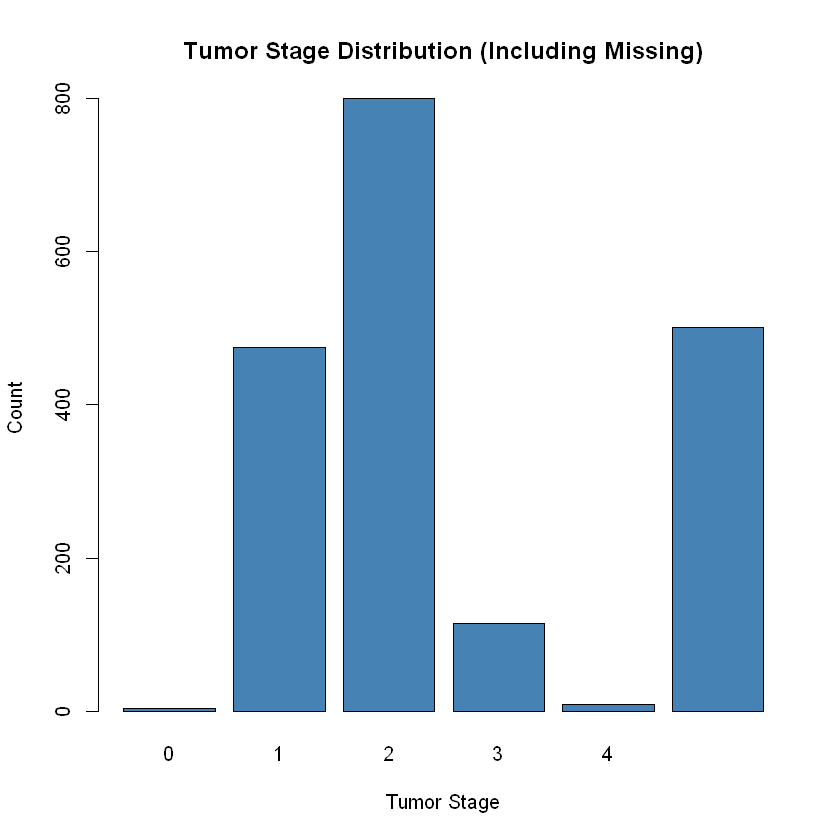

In [16]:
# Missingness distribution for `tumor_stage`

# Table for distribution plot
stage_counts <- table(addNA(clinical_vars$tumor_stage))

# Visual distribution of tumor stage
barplot(
  stage_counts,
  main = "Tumor Stage Distribution (Including Missing)",
  xlab = "Tumor Stage",
  ylab = "Count",
  col = "steelblue"
)

In [17]:
# categorical variables
cat_vars <- clinical_vars %>%
  select(where(~ is.character(.) | is.factor(.)))

names(cat_vars)

[1] "type_of_breast_surgery"         "cancer_type"                   
 [3] "cancer_type_detailed"           "cellularity"                   
 [5] "pam50_._claudin.low_subtype"    "er_status_measured_by_ihc"     
 [7] "er_status"                      "her2_status_measured_by_snp6"  
 [9] "her2_status"                    "tumor_other_histologic_subtype"
[11] "inferred_menopausal_state"      "integrative_cluster"           
[13] "primary_tumor_laterality"       "oncotree_code"                 
[15] "pr_status"                      "X3.gene_classifier_subtype"    
[17] "death_from_cancer"

In [18]:
# Transform categorical variables for modeling
clinical_vars <- clinical_vars %>%
  mutate(across(where(is.character), as.factor))

# Transform numeric categorical variables as factor
clinical_vars <- clinical_vars %>%
  mutate(
    chemotherapy = as.factor(chemotherapy),
    hormone_therapy = as.factor(hormone_therapy),
    radio_therapy = as.factor(radio_therapy),
    tumor_stage = as.factor(tumor_stage),
    cohort = as.factor(cohort)
  )

In [19]:
# Check variable types after transformation
sapply(clinical_vars, class)

age_at_diagnosis         type_of_breast_surgery 
                     "numeric"                       "factor" 
                   cancer_type           cancer_type_detailed 
                      "factor"                       "factor" 
                   cellularity                   chemotherapy 
                      "factor"                       "factor" 
   pam50_._claudin.low_subtype                         cohort 
                      "factor"                       "factor" 
     er_status_measured_by_ihc                      er_status 
                      "factor"                       "factor" 
     neoplasm_histologic_grade   her2_status_measured_by_snp6 
                     "numeric"                       "factor" 
                   her2_status tumor_other_histologic_subtype 
                      "factor"                       "factor" 
               hormone_therapy      inferred_menopausal_state 
                      "factor"                       "factor" 
           integrative_cluster       primary_tumor_laterality 
                      "factor"                       "factor" 
 lymph_nodes_examined_positive                 mutation_count 
                     "numeric"                      "numeric" 
   nottingham_prognostic_index                  oncotree_code 
                     "numeric"                       "factor" 
       overall_survival_months               overall_survival 
                     "numeric"                      "integer" 
                     pr_status                  radio_therapy 
                      "factor"                       "factor" 
    X3.gene_classifier_subtype                     tumor_size 
                      "factor"                      "numeric" 
                   tumor_stage              death_from_cancer 
                      "factor"                       "factor"

In [20]:
# Count of categorical variables after transformation
sum(sapply(clinical_vars, is.factor))

[1] 22

In [21]:
# Distribution of categorical variables
for(x in names(cat_vars)){
  print(x)
  print(table(cat_vars[[x]]))
}

[1] "type_of_breast_surgery"

                  BREAST CONSERVING        MASTECTOMY 
               22               755              1127 
[1] "cancer_type"

 Breast Cancer Breast Sarcoma 
          1903              1 
[1] "cancer_type_detailed"

                                          
                                       15 
                                   Breast 
                                       17 
         Breast Invasive Ductal Carcinoma 
                                     1500 
        Breast Invasive Lobular Carcinoma 
                                      142 
 Breast Invasive Mixed Mucinous Carcinoma 
                                       22 
Breast Mixed Ductal and Lobular Carcinoma 
                                      207 
                Metaplastic Breast Cancer 
                                        1 
[1] "cellularity"

             High      Low Moderate 
      54      939      200      711 
[1] "pam50_._claudin.low_subtype"

      Basal claudin-l

## Decisions
- Impute 26% missingness
- Remove `cancer_type` 'Breast Sarcoma' due to sample size of **1** in with 2nd class at ~1900

In [22]:
# Imputation is random sampling
set.seed(2026) 

# Re-define `tumor_stage` as character for imputation
tumor_stage_chr <- as.character(clinical_vars$tumor_stage)

# Pre-imputation distribution of `tumor_stage`
stage_dist <- prop.table(table(tumor_stage_chr, useNA = "no"))
cat("Observed tumor_stage distribution (pre-impute):\n")
print(stage_dist)

# Identify indices of missing `tumor_stage` values
missing_idx <- which(is.na(tumor_stage_chr))

# Impute missing `tumor_stage` values based on observed distribution
tumor_stage_chr[missing_idx] <- sample(
  x = names(stage_dist),
  size = length(missing_idx),
  replace = TRUE,
  prob = as.numeric(stage_dist)
)

# Convert back to factor
clinical_vars$tumor_stage <- factor(tumor_stage_chr)

# Post-imputation distribution of `tumor_stage`
cat("Observed tumor_stage distribution (post-impute):\n")
print(prop.table(table(clinical_vars$tumor_stage, useNA = "ifany")))
cat("\n","Number of missing values after imputation: ", sum(is.na(clinical_vars$tumor_stage)))

Observed tumor_stage distribution (pre-impute):
tumor_stage_chr
          0           1           2           3           4 
0.002851033 0.338560228 0.570206700 0.081967213 0.006414825 
Observed tumor_stage distribution (post-impute):

          0           1           2           3           4 
0.002100840 0.339810924 0.573004202 0.079306723 0.005777311 

 Number of missing values after imputation:  0

# **Pre-processing gene predictor variables**

In [23]:
# Quick glance at shape, types, and classes
str(gene_vars)

'data.frame':	1904 obs. of  489 variables:
 $ brca1    : num  -1.399 -1.38 0.067 0.674 1.293 ...
 $ brca2    : num  -0.574 0.278 -0.843 -0.543 -0.904 ...
 $ palb2    : num  -1.622 -1.215 0.211 -1.659 -0.722 ...
 $ pten     : num  1.452 0.53 -0.333 0.637 0.217 ...
 $ tp53     : num  0.3504 -0.0136 0.5141 1.6708 0.3484 ...
 $ atm      : num  1.1517 -0.2659 -0.0803 -0.888 0.3897 ...
 $ cdh1     : num  0.0348 1.3594 1.1398 1.2491 0.9131 ...
 $ chek2    : num  0.127 0.796 0.419 -1.189 0.936 ...
 $ nbn      : num  -0.836 0.542 -0.403 -0.417 0.767 ...
 $ nf1      : num  -0.858 -2.606 -1.131 -0.617 -0.294 ...
 $ stk11    : num  -0.429 0.512 0.236 1.008 -0.296 ...
 $ bard1    : num  -1.12 0.439 -0.172 -0.401 0.632 ...
 $ mlh1     : num  -0.484 1.227 -1.791 -1.391 -0.358 ...
 $ msh2     : num  -0.748 0.761 3.095 4.88 0.303 ...
 $ msh6     : num  -1.666 0.1821 0.6608 0.0615 0.8747 ...
 $ pms2     : num  -0.125 1.01 2.613 2.941 0.632 ...
 $ epcam    : num  -0.372 0.56 2.555 4.116 0.335 ...
 $ rad5

In [24]:
# Check if all gene expression variables are numeric
numeric <- all(sapply(gene_vars, is.numeric))
numeric

[1] TRUE

In [25]:
# Check missingness in gene expression variables
gene_missing <- data.frame(
  variable = names(gene_vars),
  missing = colSums(is.na(gene_vars)),
  missing_pct = round(colMeans(is.na(gene_vars)) * 100, 3)
)

# View missing data variables
gene_missing <- gene_missing[gene_missing$missing > 0, ]
gene_missing

variable,missing,missing_pct
<chr>,<dbl>,<dbl>


In [26]:
# Looking at mean and variance of gene expression variables
summary(gene_vars)

     brca1                brca2                palb2           
 Min.   :-2.4444000   Min.   :-2.7835000   Min.   :-4.3846000  
 1st Qu.:-0.7198500   1st Qu.:-0.6994750   1st Qu.:-0.6798250  
 Median :-0.1244500   Median :-0.0582000   Median :-0.0221000  
 Mean   :-0.0000006   Mean   :-0.0000004   Mean   : 0.0000004  
 3rd Qu.: 0.5532250   3rd Qu.: 0.6290000   3rd Qu.: 0.6400000  
 Max.   : 4.5542000   Max.   : 3.7379000   Max.   : 4.6150000  
      pten                 tp53                 atm            
 Min.   :-5.9328000   Min.   :-2.4812000   Min.   :-3.1705000  
 1st Qu.:-0.5586500   1st Qu.:-0.6661500   1st Qu.:-0.6602250  
 Median : 0.1098500   Median :-0.0301000   Median :-0.0042000  
 Mean   :-0.0000009   Mean   : 0.0000006   Mean   :-0.0000002  
 3rd Qu.: 0.6426250   3rd Qu.: 0.6447500   3rd Qu.: 0.6901500  
 Max.   : 3.2541000   Max.   : 4.2898000   Max.   : 3.8242000  
      cdh1                chek2              nbn            
 Min.   :-3.3237000   Min.   :-2.6887   Min

In [27]:
# Scale gene expression variables for modeling
gene_vars_scaled <- scale(gene_vars)
summary(gene_vars_scaled)

     brca1             brca2              palb2               pten        
 Min.   :-2.4438   Min.   :-2.78277   Min.   :-4.38345   Min.   :-5.9312  
 1st Qu.:-0.7197   1st Qu.:-0.69929   1st Qu.:-0.67965   1st Qu.:-0.5585  
 Median :-0.1244   Median :-0.05818   Median :-0.02209   Median : 0.1098  
 Mean   : 0.0000   Mean   : 0.00000   Mean   : 0.00000   Mean   : 0.0000  
 3rd Qu.: 0.5531   3rd Qu.: 0.62884   3rd Qu.: 0.63983   3rd Qu.: 0.6425  
 Max.   : 4.5530   Max.   : 3.73692   Max.   : 4.61379   Max.   : 3.2532  
      tp53               atm                 cdh1             chek2        
 Min.   :-2.48055   Min.   :-3.169668   Min.   :-3.3228   Min.   :-2.6880  
 1st Qu.:-0.66598   1st Qu.:-0.660052   1st Qu.:-0.4585   1st Qu.:-0.7384  
 Median :-0.03009   Median :-0.004199   Median : 0.1155   Median :-0.1311  
 Mean   : 0.00000   Mean   : 0.000000   Mean   : 0.0000   Mean   : 0.0000  
 3rd Qu.: 0.64458   3rd Qu.: 0.689969   3rd Qu.: 0.6496   3rd Qu.: 0.5430  
 Max.   : 4.28867  

In [28]:
# Verify dimensions of scaled gene variables to ensure no data loss during scaling
dim(gene_vars_scaled)

[1] 1904  489

# **Pre-processing mutation predictor variables**

In [29]:
# Unique values in mutation variables
table_values <- data.frame(table(unlist(mutation_vars)))

# mutation frequency
table_values %>% 
  arrange(desc(Freq)) %>%
  head(10)

n_distinct(table_values)

,Var1,Freq
,<fct>,<int>
1,0,319653
2,H1047R,285
3,E545K,127
4,E542K,73
5,E17K,63
6,X308_splice,59
7,N345K,42
8,K700E,36
9,R175H,34


[1] 7668

In [30]:
# Check missingness in mutation variables
mutation_missing <- data.frame(
  variable = names(mutation_vars),
  missing = colSums(is.na(mutation_vars)),
  missing_pct = round(colMeans(is.na(mutation_vars)) * 100, 3)
)

mutation_missing <- mutation_missing[mutation_missing$missing > 0, ]
mutation_missing

variable,missing,missing_pct
<chr>,<dbl>,<dbl>


In [31]:
# Transform mutation variables to binary (0 = no mutation, 1 = mutation)
mutation_vars_bin <- mutation_vars %>%
  mutate(across(
    everything(),
    ~ {
      x <- as.character(.)
      x <- trimws(x)
      ifelse(x == "0" | is.na(x) | x == "", 0, 1)
    }
  )) %>%
  mutate(across(everything(), as.integer))

In [32]:
# Check unique values after transformation (and distribution)
table(unlist(mutation_vars_bin), useNA = "ifany")


     0      1 
319653   9739 

# **Combining back into single df**

In [33]:
# Dimensions need to be consistent across all datasets to merge
nrow(clinical_vars)
nrow(gene_vars_scaled)
nrow(mutation_vars_bin)

[1] 1904

[1] 1904

[1] 1904

In [34]:
# Only processed rows
keep_rows <- complete.cases(
  clinical_vars,
  gene_vars_scaled,
  mutation_vars_bin
)

# Row removals
keep_rows <- keep_rows & clinical_vars$cancer_type != "Breast Sarcoma"

# applying row filter 
clinical_vars      <- clinical_vars[keep_rows, ]
gene_vars_scaled   <- gene_vars_scaled[keep_rows, ]
mutation_vars_bin  <- mutation_vars_bin[keep_rows, ]

# target variables 
time_var  <- clinical_vars$overall_survival_months
event_var <- clinical_vars$overall_survival

# Column removals (not useful or harmful to model)
clinical_vars <- clinical_vars %>% 
  select(
    -any_of(c(
      "death_from_cancer", # outcome leak
      "cohort", # groups of people
      "patient_id", # identifier
      "overall_survival", # outcome leak
      "overall_survival_months", # outcome leak
      "nottingham_prognostic_index" # outcome leak - clinical tool used to predict survival 
    ))
  )

# Re-combine
model_df <- data.frame(clinical_vars, gene_vars_scaled, mutation_vars_bin)

In [35]:
# Final checks

# Checking removal of "Breast Sarcoma" cancer type
table(clinical_vars$cancer_type)

# Number of removed rows due to missingness or intentional removal
sum(!keep_rows)

# Final dimensions of datasets after filtering
dim(model_df)


 Breast Cancer Breast Sarcoma 
          1770              0 

[1] 134

[1] 1770  687

# **Part 1: Model Selection Methods**

In [36]:
# Create survival object for modeling
surv_object <- Surv(time_var, event_var)
surv_object

   [1]  84.6333333  163.7000000+ 164.9333333   41.3666667+   7.8000000+
   [6] 164.3333333   99.5333333+  36.5666667+  36.2666667+ 132.0333333+
  [11] 163.5333333   14.1333333+ 160.3000000   62.8666667  140.8666667 
  [16] 153.9666667  157.4333333  103.1333333   28.5000000+  69.5000000 
  [21]  86.0666667+ 153.2000000   49.7666667+  98.7000000    8.0666667+
  [26] 148.0333333  140.7666667+  85.3333333  158.0333333   42.7000000+
  [31] 112.4000000+ 127.1000000   39.1666667+  13.4000000   66.7333333+
  [36] 122.2666667    2.4000000   95.8666667+  29.0666667+ 152.2000000 
  [41] 138.9000000  114.2333333+ 118.2000000    1.2666667  132.0666667 
  [46] 137.8000000   66.6333333+ 151.0000000   12.9333333+  88.2000000 
  [51] 150.5666667  109.2000000  147.9333333   54.3333333+ 152.0666667+
  [56] 147.6666667   51.7666667+   1.7666667   51.7000000+ 111.2000000 
  [61]  49.2333333+  63.0333333  114.7666667   59.8000000  114.7666667 
  [66]  55.7666667   98.1000000+  10.8333333   47.6333333+ 104.4

## Best Subset Selection

In [37]:
# Numeric predictors
clinical_num_vars <- clinical_vars %>% select(where(is.numeric))

# Create clean numeric results table
clinical_num_cor <- data.frame(
  correlation_with_survival = sapply(clinical_num_vars, function(x) cor(x, time_var, use = "complete.obs"))
)

numeric_results <- 
  clinical_num_cor %>%
  arrange(desc(abs(correlation_with_survival))) %>%
  head(10) %>%
  round(3)

numeric_results

,correlation_with_survival
,<dbl>
lymph_nodes_examined_positive,-0.234
tumor_size,-0.196
age_at_diagnosis,-0.156
neoplasm_histologic_grade,-0.120
mutation_count,0.049


In [38]:
# Categorical predictors
factor_vars <- clinical_vars[, sapply(clinical_vars, is.factor)]

# Categorical scores
anova_scores <- sapply(
  factor_vars,
  function(x) {
    if(length(unique(x)) > 1) {
      round(summary(aov(time_var ~ x))[[1]][["F value"]][1],3)
    } else {
      NA
    }
  }
)

# subset_f_value_table
head(data.frame( F_value = sort(anova_scores, decreasing = TRUE, na.last = NA)), 10)

,F_value
,<dbl>
chemotherapy,46.911
pr_status,39.737
her2_status,31.619
er_status,26.126
tumor_stage,23.792
hormone_therapy,20.566
type_of_breast_surgery,14.236
primary_tumor_laterality,12.533
X3.gene_classifier_subtype,10.387


In [39]:
# subset dataframe
subset_df <- clinical_vars[, c(
  "chemotherapy",
  "pr_status",
  "her2_status",
  "er_status",
  "tumor_stage",
  "mutation_count",
  "lymph_nodes_examined_positive",
  "tumor_size",
  "age_at_diagnosis",
  "neoplasm_histologic_grade"
)]
head(subset_df)

,chemotherapy,pr_status,her2_status,er_status,tumor_stage,mutation_count,lymph_nodes_examined_positive,tumor_size,age_at_diagnosis,neoplasm_histologic_grade
,<fct>,<fct>,<fct>,<fct>,<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
2,0,Positive,Negative,Positive,1,2,0,10,43.19,3
3,1,Positive,Negative,Positive,2,2,1,15,48.87,2
4,1,Positive,Negative,Positive,2,1,3,25,47.68,2
5,1,Positive,Negative,Positive,2,2,8,40,76.97,3
6,0,Positive,Negative,Positive,4,4,0,31,78.77,3
7,1,Positive,Negative,Positive,2,4,1,10,56.45,2


In [40]:
reg_exhaustive <- regsubsets(
  time_var ~ .,
  data = subset_df,
  nvmax = 10,
  method = "exhaustive"
)

reg_exhaustive_summary <- summary(reg_exhaustive)

Warning message in leaps.setup(x, y, wt = wt, nbest = nbest, nvmax = nvmax, force.in = force.in, :
"1  linear dependencies found"


Reordering variables and trying again:


In [41]:
subset_results <- data.frame(
  Criterion = c("Adjusted R-squared", "Cp", "BIC"),
  Optimal_Number_of_Predictors = c(
    which.max(reg_exhaustive_summary$adjr2),
    which.min(reg_exhaustive_summary$cp),
    which.min(reg_exhaustive_summary$bic)
  ),
  Min = c(
    min(reg_exhaustive_summary$adjr2),
    min(reg_exhaustive_summary$cp),
    min(reg_exhaustive_summary$bic)
  )
)

subset_results

Criterion,Optimal_Number_of_Predictors,Min
<chr>,<int>,<dbl>
Adjusted R-squared,11,0.05424538
Cp,10,9.90607459
BIC,6,-211.08380041


In [42]:
final_model <- coef(reg_exhaustive, id = 6)

final_model_table <- data.frame(
  Predictor = names(final_model),
  Coefficient = round(final_model, 3)
)

final_model_table

,Predictor,Coefficient
,<chr>,<dbl>
(Intercept),(Intercept),246.909
chemotherapy1,chemotherapy1,-35.553
pr_statusPositive,pr_statusPositive,9.976
her2_statusPositive,her2_statusPositive,-21.898
tumor_size,tumor_size,-0.643
age_at_diagnosis,age_at_diagnosis,-1.465
neoplasm_histologic_grade,neoplasm_histologic_grade,-4.520


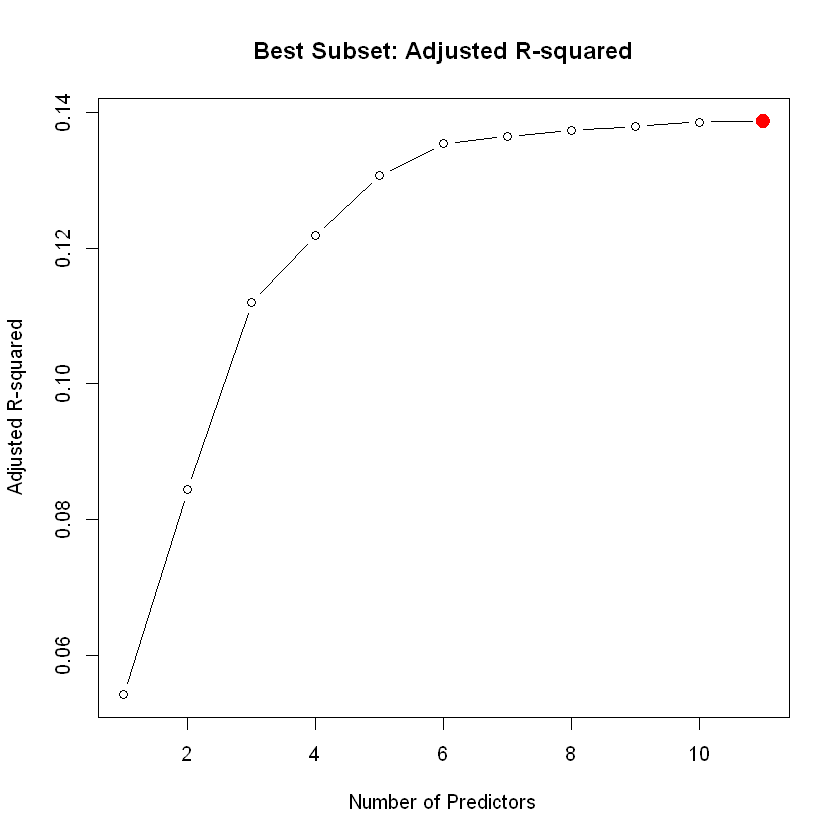

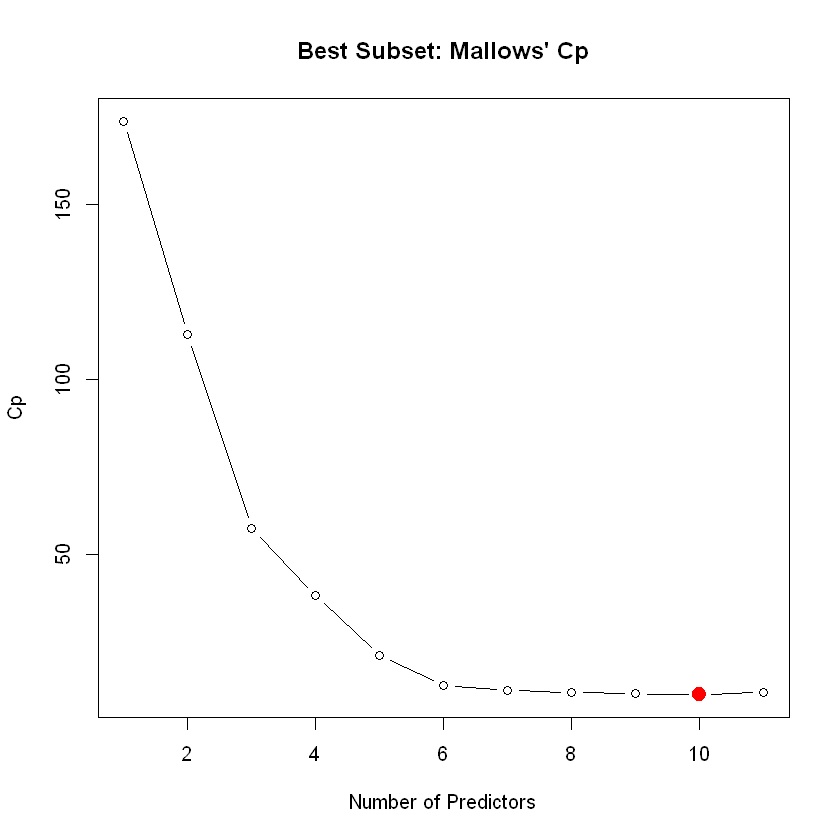

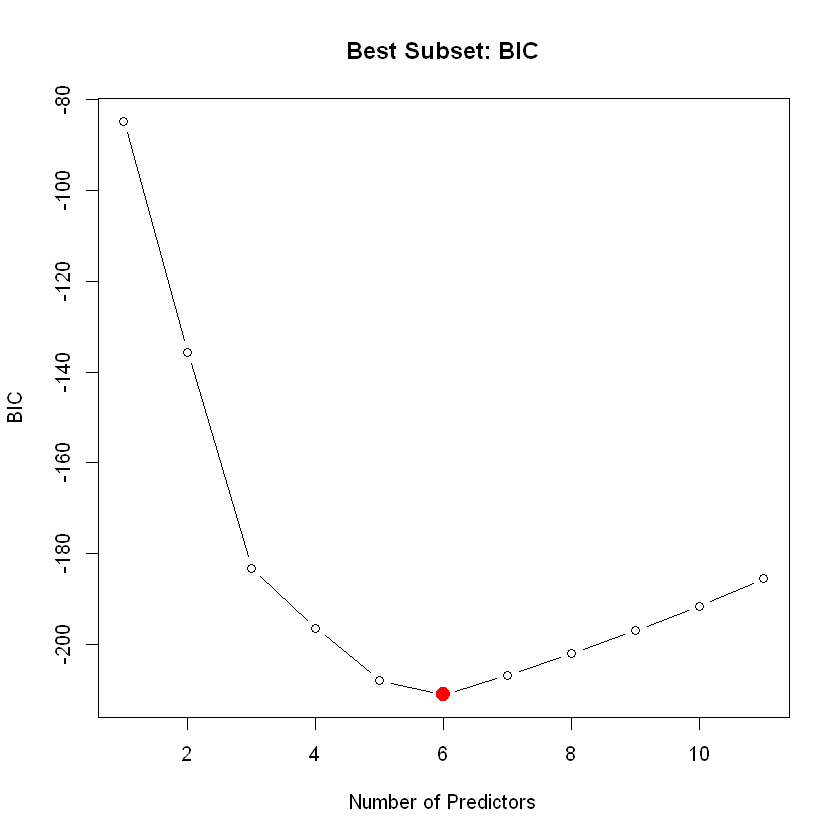

In [43]:
# graphs
plot(
  reg_exhaustive_summary$adjr2,
  type = "b",
  xlab = "Number of Predictors",
  ylab = "Adjusted R-squared",
  main = "Best Subset: Adjusted R-squared"
)
points(
  which.max(reg_exhaustive_summary$adjr2),
  max(reg_exhaustive_summary$adjr2),
  col = "red", pch = 19, cex = 1.5
)

plot(
  reg_exhaustive_summary$cp,
  type = "b",
  xlab = "Number of Predictors",
  ylab = "Cp",
  main = "Best Subset: Mallows' Cp"
)
points(
  which.min(reg_exhaustive_summary$cp),
  min(reg_exhaustive_summary$cp),
  col = "red", pch = 19, cex = 1.5
)

plot(
  reg_exhaustive_summary$bic,
  type = "b",
  xlab = "Number of Predictors",
  ylab = "BIC",
  main = "Best Subset: BIC"
)
points(
  which.min(reg_exhaustive_summary$bic),
  min(reg_exhaustive_summary$bic),
  col = "red", pch = 19, cex = 1.5
)

## Substep results:

#### Exhaustive
- adjr2: 10
- Mallows Cp: 10
- BIC: 6

#### Substep variables chosen 
- AIC was best fit, you can see visually it stopped when it was at it's lowest point. 
- 'lymph_nodes_examined_positive', 'tumor_size', 'age_at_diagnosis', 'chemotherapy1','pr_statusPositive', 'her2_statusPositive'

In [44]:
# Cox subset model with variables from sequential replacement selection
cox_subset <- coxph(
  surv_object ~
    lymph_nodes_examined_positive +
    tumor_size +
    age_at_diagnosis +
    chemotherapy +
    pr_status +
    her2_status,
  data = clinical_vars
)

summary(cox_subset)

Call:
coxph(formula = surv_object ~ lymph_nodes_examined_positive + 
    tumor_size + age_at_diagnosis + chemotherapy + pr_status + 
    her2_status, data = clinical_vars)

  n= 1770, number of events= 744 

                                   coef exp(coef)  se(coef)      z Pr(>|z|)    
lymph_nodes_examined_positive  0.005439  1.005454  0.014416  0.377    0.706    
tumor_size                    -0.002753  0.997250  0.003059 -0.900    0.368    
age_at_diagnosis              -0.001799  0.998202  0.003429 -0.525    0.600    
chemotherapy1                  0.534836  1.707169  0.109887  4.867 1.13e-06 ***
pr_statusPositive              0.026205  1.026552  0.080767  0.324    0.746    
her2_statusPositive            0.175929  1.192353  0.123612  1.423    0.155    
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

                              exp(coef) exp(-coef) lower .95 upper .95
lymph_nodes_examined_positive    1.0055     0.9946    0.9774     1.034
tumor_size            

In [45]:
# Create table of hazard ratios and significant p-values for interpretation
interpret_table <- data.frame(
  Hazard_Ratio = summary(cox_subset)$coefficients[,2],
  p_value = summary(cox_subset)$coefficients[,5]
)

interpret_table <- interpret_table[!is.na(interpret_table$Hazard_Ratio), ]
interpret_table <- interpret_table[interpret_table$p_value < 0.05, ]

interpret_table %>%
  arrange(Hazard_Ratio)

,Hazard_Ratio,p_value
,<dbl>,<dbl>
chemotherapy1,1.707169,1.132241e-06


## **Key Predictors:**

#### Significant predictors:
- Hazard ratio answers "how large of an effect". Acts as a multiple of. So,
- 1 means no effect
- x > 1 = increased risk 
- x < 1 = decreased risk

### **Higher Risk:**
- chemotherapy1 ~1.71

### **Performance:**
- Concordance= 0.568  (se = 0.013 )

## Stepwise Selection

In [46]:
clinical_subset_df <- clinical_vars |>
  subset(select = -c(cancer_type_detailed, oncotree_code))

In [47]:
set.seed(2026)

# Full Cox model with all clinical variables
cox_full <- coxph(
  surv_object ~ .,
  data = clinical_subset_df
)

# Model selection using AIC and BIC
cox_aic <- step(cox_full, direction = "both", trace = 0)
cox_bic <- step(cox_full, direction = "both", k = log(nrow(clinical_subset_df)), trace = 0)

# summaries
summary(cox_aic)
summary(cox_bic)

Call:
coxph(formula = surv_object ~ type_of_breast_surgery + chemotherapy + 
    er_status + neoplasm_histologic_grade + her2_status_measured_by_snp6 + 
    tumor_other_histologic_subtype + hormone_therapy + primary_tumor_laterality + 
    lymph_nodes_examined_positive + mutation_count + X3.gene_classifier_subtype, 
    data = clinical_subset_df)

  n= 1770, number of events= 744 

                                                      coef exp(coef) se(coef)
type_of_breast_surgeryBREAST CONSERVING           -1.07321   0.34191  0.44805
type_of_breast_surgeryMASTECTOMY                  -1.40986   0.24418  0.44778
chemotherapy1                                      0.69217   1.99805  0.11489
er_statusPositive                                 -0.38157   0.68279  0.16173
neoplasm_histologic_grade                         -0.15916   0.85286  0.06922
her2_status_measured_by_snp6LOSS                   0.20851   1.23184  0.19002
her2_status_measured_by_snp6NEUTRAL               -0.17223   0.84179 

Call:
coxph(formula = surv_object ~ type_of_breast_surgery + chemotherapy + 
    hormone_therapy + mutation_count, data = clinical_subset_df)

  n= 1770, number of events= 744 

                                            coef exp(coef) se(coef)      z
type_of_breast_surgeryBREAST CONSERVING -1.11308   0.32855  0.41584 -2.677
type_of_breast_surgeryMASTECTOMY        -1.44841   0.23494  0.41563 -3.485
chemotherapy1                            0.66284   1.94030  0.09055  7.320
hormone_therapy1                         0.52245   1.68616  0.07941  6.579
mutation_count                          -0.04194   0.95893  0.01170 -3.583
                                        Pr(>|z|)    
type_of_breast_surgeryBREAST CONSERVING 0.007436 ** 
type_of_breast_surgeryMASTECTOMY        0.000492 ***
chemotherapy1                           2.48e-13 ***
hormone_therapy1                        4.74e-11 ***
mutation_count                          0.000339 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '

In [61]:
model_compare <- data.frame(
  Model = c("Subset Cox", "Stepwise AIC", "Stepwise BIC"),
  Predictors = c(
    length(coef(cox_subset)),
    length(coef(cox_aic)),
    length(coef(cox_bic))
  ),
  Concordance = c(
    summary(cox_subset)$concordance[1],
    summary(cox_aic)$concordance[1],
    summary(cox_bic)$concordance[1]
  ),
  AIC = c(
    extractAIC(cox_subset)[2],
    extractAIC(cox_aic)[2],
    extractAIC(cox_bic)[2]
  )
)

model_compare %>%
  arrange(desc(Concordance))

Model,Predictors,Concordance,AIC
<chr>,<int>,<dbl>,<dbl>
Stepwise AIC,25,0.6541424,8904.374
Stepwise BIC,5,0.6331431,8932.053
Subset Cox,6,0.5683458,9024.338


## Compare subset to stepwise

### Subset Selection (minimized)
- Predictors: 6
- Concordance: 0.568
- AIC: 9024.338

### Stepwise Selection (both)
##### AIC:
- Predictors: 25
- Concordance: 0.654
- AIC: 8904.374
> Better model. Concordance represents prediction for survival order. AIC is also a lower score comparatively thus far which represents statistical fit.

##### BIC:
- Predictors: 5
- Concordance: 0.633
- AIC: 8932.053

### Summary
- Stepwise BIC penalizes complexity more, so fewer variables are capturing more at a cost represented in concordance score.
- Our goal is not to find the simplest highest performing model, better performance is preferred as long as it doesn't overfit.
- Stepwise AIC score remained roughly the same since they're capturing roughly the same structure.
- Subset selected model captured a more linear trend, not likeihood. AIC is worse as opposed to stepwise that used cox.
- Subset performed the worst in this case despite having the most coefficients.

# **Part 2: Regularization and 5-fold cross-validation**

In [49]:
# Convert clinical predictors to matrix format required by glmnet
X <- model.matrix(~ . - 1, data = model_df) # Remove intercept
y <- surv_object

In [50]:
# Random test-train split (80-20)
set.seed(2026)

n <- nrow(X)
train_idx <- sample(seq_len(n), size = floor(0.8 * n))

X_train <- X[train_idx, ]
X_test  <- X[-train_idx, ]

y_train <- y[train_idx]
y_test  <- y[-train_idx]

# Ridge

In [51]:
# cv randomness
set.seed(2026)

# Fit ridge regression
cv_ridge <- cv.glmnet(
  x = X_train,
  y = y_train,
  family = "cox",
  alpha = 0,          # ridge
  nfolds = 5,
  standardize = TRUE
)

# Optimal lambda values
cat("Ridge lambda.min:", cv_ridge$lambda.min, "\n")
cat("Ridge lambda.1se:", cv_ridge$lambda.1se, "\n")

Ridge lambda.min: 2.1893 
Ridge lambda.1se: 32.51041 


In [52]:
# Coefficients at optimal lambda values
ridge_coef_min <- coef(cv_ridge, s = "lambda.min")
ridge_coef_1se <- coef(cv_ridge, s = "lambda.1se")

ridge_coef_min
ridge_coef_1se

732 x 1 sparse Matrix of class "dgCMatrix"
                                                                          1
age_at_diagnosis                                              -9.227717e-05
type_of_breast_surgery                                         1.333373e-01
type_of_breast_surgeryBREAST CONSERVING                        3.378053e-02
type_of_breast_surgeryMASTECTOMY                              -3.856611e-02
cancer_typeBreast Sarcoma                                      .           
cancer_type_detailedBreast                                    -3.750738e-02
cancer_type_detailedBreast Invasive Ductal Carcinoma           7.415666e-03
cancer_type_detailedBreast Invasive Lobular Carcinoma          4.734202e-03
cancer_type_detailedBreast Invasive Mixed Mucinous Carcinoma  -7.101656e-03
cancer_type_detailedBreast Mixed Ductal and Lobular Carcinoma -2.587136e-02
cancer_type_detailedMetaplastic Breast Cancer                  .           
cellularityHigh                              

732 x 1 sparse Matrix of class "dgCMatrix"
                                                                          1
age_at_diagnosis                                              -3.658284e-05
type_of_breast_surgery                                         1.089015e-02
type_of_breast_surgeryBREAST CONSERVING                        3.475006e-03
type_of_breast_surgeryMASTECTOMY                              -3.855700e-03
cancer_typeBreast Sarcoma                                      .           
cancer_type_detailedBreast                                    -3.745513e-03
cancer_type_detailedBreast Invasive Ductal Carcinoma           9.510426e-04
cancer_type_detailedBreast Invasive Lobular Carcinoma          7.943204e-04
cancer_type_detailedBreast Invasive Mixed Mucinous Carcinoma  -1.737549e-04
cancer_type_detailedBreast Mixed Ductal and Lobular Carcinoma -2.770312e-03
cancer_type_detailedMetaplastic Breast Cancer                  .           
cellularityHigh                              

In [53]:
# Predict risk scores on test set using optimal lambda values
ridge_risk_min <- predict(cv_ridge, newx = X_test, s = "lambda.min", type = "link")
ridge_risk_1se <- predict(cv_ridge, newx = X_test, s = "lambda.1se", type = "link")

# Calculate concordance for ridge models
ridge_conc_min <- concordance(y_test ~ ridge_risk_min, reverse = TRUE)
ridge_conc_1se <- concordance(y_test ~ ridge_risk_1se, reverse = TRUE)

# Display concordance values
ridge_conc_min$concordance
ridge_conc_1se$concordance

[1] 0.6851928

[1] 0.6597237

# Lasso

In [54]:
# cv randomness
set.seed(2026)

# Fit lasso regression
cv_lasso <- cv.glmnet(
  x = X_train,
  y = y_train,
  family = "cox",
  alpha = 1,         # lasso
  nfolds = 5,
  standardize = TRUE
)

# Optimal lambda values
cat("LASSO lambda.min:", cv_lasso$lambda.min, "\n")
cat("LASSO lambda.1se:", cv_lasso$lambda.1se, "\n")

Warning message:
"from glmnet C++ code (error code -30090); Numerical error at 90th lambda value; solutions for larger values of lambda returned"
Warning message:
"from glmnet C++ code (error code -30094); Numerical error at 94th lambda value; solutions for larger values of lambda returned"


LASSO lambda.min: 0.02962228 
LASSO lambda.1se: 0.09928211 


In [55]:
# Coefficients at optimal lambda values
lasso_coef_min <- coef(cv_lasso, s = "lambda.min")
lasso_coef_1se <- coef(cv_lasso, s = "lambda.1se")

lasso_coef_min
lasso_coef_1se

732 x 1 sparse Matrix of class "dgCMatrix"
                                                                         1
age_at_diagnosis                                               .          
type_of_breast_surgery                                         .          
type_of_breast_surgeryBREAST CONSERVING                        .          
type_of_breast_surgeryMASTECTOMY                              -0.198354982
cancer_typeBreast Sarcoma                                      .          
cancer_type_detailedBreast                                     .          
cancer_type_detailedBreast Invasive Ductal Carcinoma           .          
cancer_type_detailedBreast Invasive Lobular Carcinoma          .          
cancer_type_detailedBreast Invasive Mixed Mucinous Carcinoma   .          
cancer_type_detailedBreast Mixed Ductal and Lobular Carcinoma  .          
cancer_type_detailedMetaplastic Breast Cancer                  .          
cellularityHigh                                          

732 x 1 sparse Matrix of class "dgCMatrix"
                                                                       1
age_at_diagnosis                                              .         
type_of_breast_surgery                                        .         
type_of_breast_surgeryBREAST CONSERVING                       .         
type_of_breast_surgeryMASTECTOMY                              .         
cancer_typeBreast Sarcoma                                     .         
cancer_type_detailedBreast                                    .         
cancer_type_detailedBreast Invasive Ductal Carcinoma          .         
cancer_type_detailedBreast Invasive Lobular Carcinoma         .         
cancer_type_detailedBreast Invasive Mixed Mucinous Carcinoma  .         
cancer_type_detailedBreast Mixed Ductal and Lobular Carcinoma .         
cancer_type_detailedMetaplastic Breast Cancer                 .         
cellularityHigh                                               .         
cellular

In [56]:
# Nonzero predictors for lasso
selected_vars_min <- rownames(lasso_coef_min)[as.vector(lasso_coef_min) != 0]
selected_vars_1se <- rownames(lasso_coef_1se)[as.vector(lasso_coef_1se) != 0]

# Zero predictors for lasso
zero_vars_min <- rownames(lasso_coef_min)[as.vector(lasso_coef_min) == 0]
zero_vars_1se <- rownames(lasso_coef_1se)[as.vector(lasso_coef_1se) == 0]

# Display selected and zero variables
length(selected_vars_min)
length(selected_vars_1se)
length(zero_vars_min)
length(zero_vars_1se)

[1] 58

[1] 5

[1] 674

[1] 727

In [57]:
# Predict risks for lasso models
lasso_risk_min <- predict(cv_lasso, newx = X_test, s = "lambda.min", type = "link")
lasso_risk_1se <- predict(cv_lasso, newx = X_test, s = "lambda.1se", type = "link")

# Calculate concordance
lasso_conc_min <- concordance(y_test ~ lasso_risk_min, reverse = TRUE)
lasso_conc_1se <- concordance(y_test ~ lasso_risk_1se, reverse = TRUE)

# Display concordance results
lasso_conc_min$concordance
lasso_conc_1se$concordance

[1] 0.7062281

[1] 0.659569

## Plots

In [58]:
# Fit ridge and lasso regression without cross-validation to get full coefficient paths
ridge_fit <- glmnet(X_train, y_train, family = "cox", alpha = 0, standardize = TRUE)
lasso_fit <- glmnet(X_train, y_train, family = "cox", alpha = 1, standardize = TRUE)

# Count nonzero coefficients across the full lambda path for lasso
nonzero_counts <- apply(as.matrix(coef(lasso_fit)), 2, function(x) sum(x != 0))

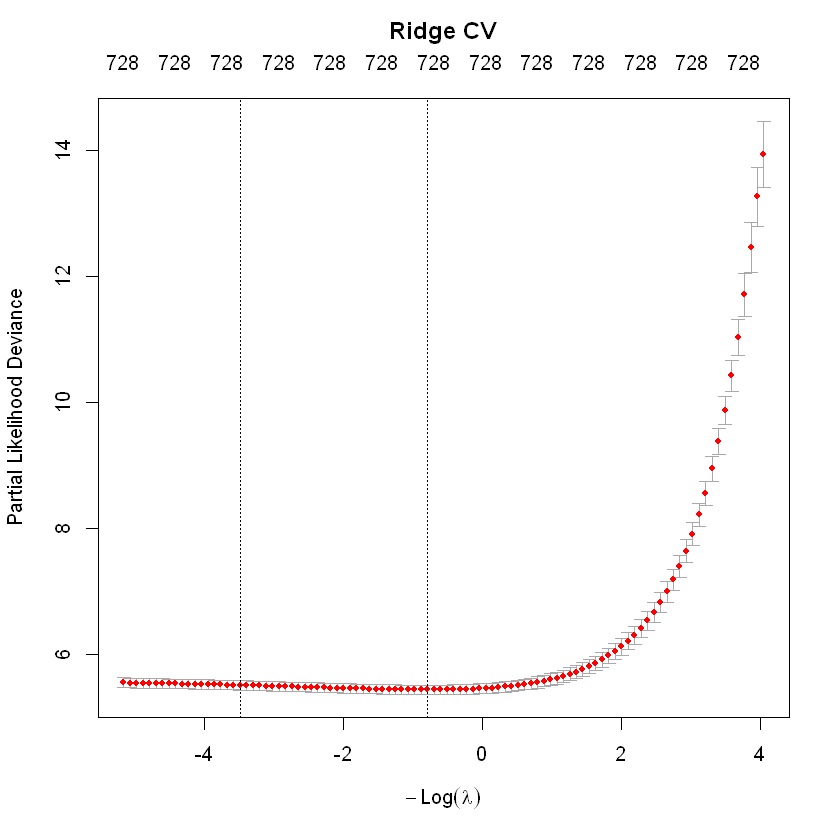

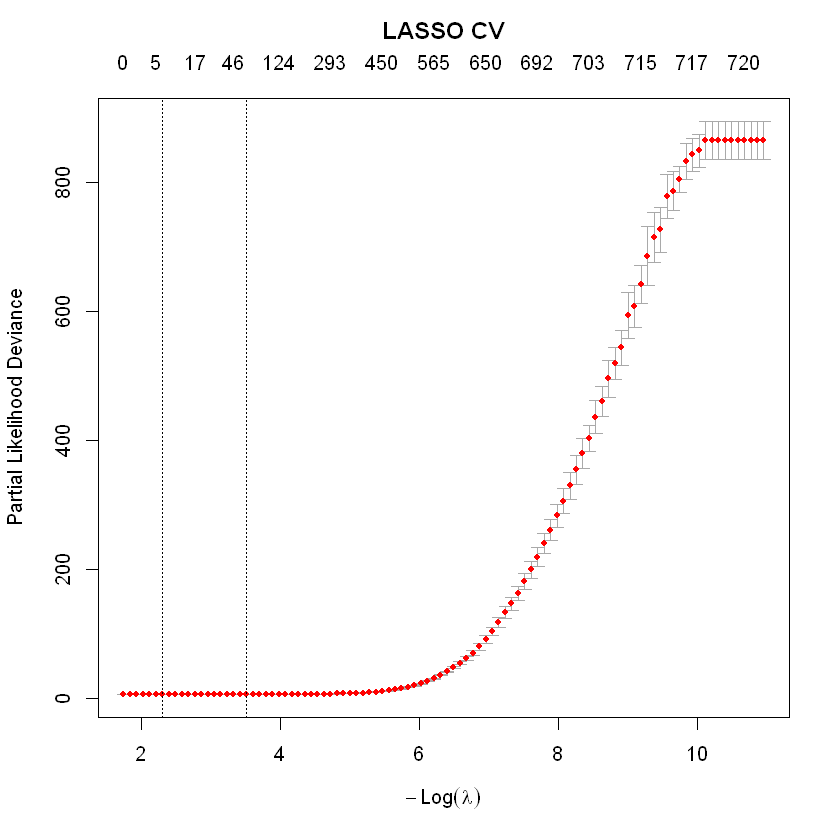

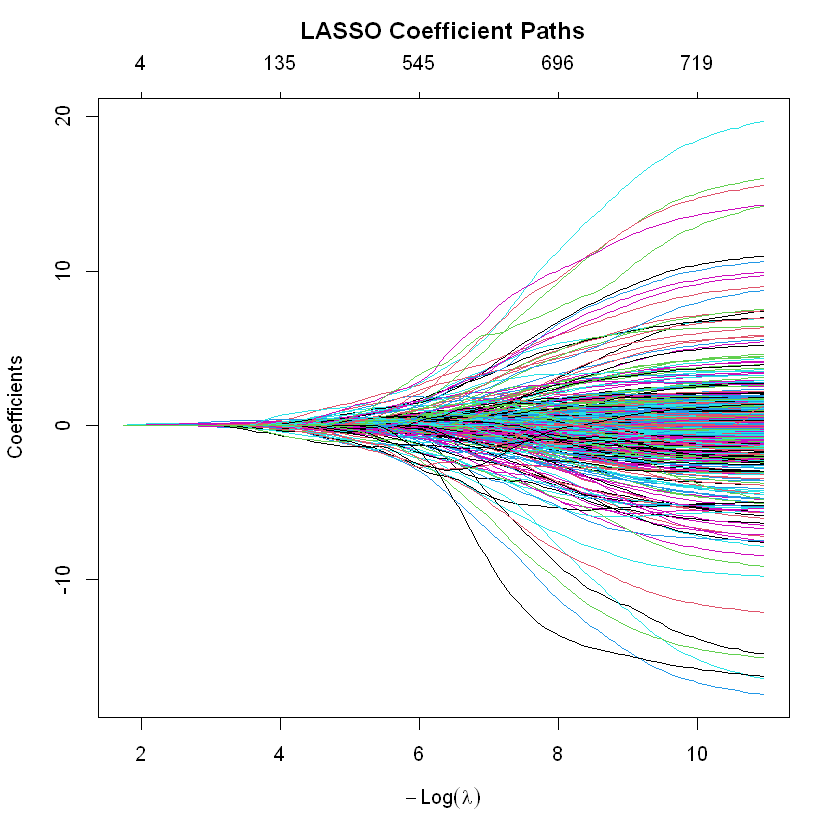

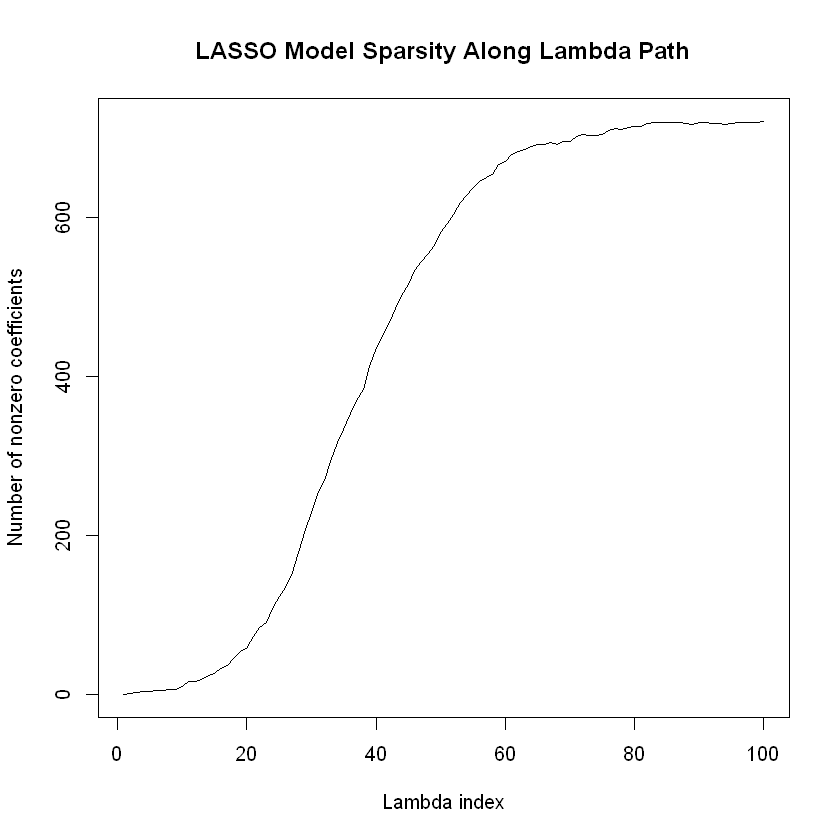

In [59]:
# Plots
plot(cv_ridge)
     title(main = "Ridge CV", line = 2.5)

plot(cv_lasso)
     title(main = "LASSO CV", line = 2.5)

plot(lasso_fit, xvar = "lambda")
     title(main = "LASSO Coefficient Paths", line = 2.5)
     
plot(nonzero_counts, type = "l",
     xlab = "Lambda index",
     ylab = "Number of nonzero coefficients",
     main = "LASSO Model Sparsity Along Lambda Path")

In [60]:
# Final interpretation table for model comparison on dataset.
final_models <- data.frame(
  Model = c(
    "Subset Cox",
    "Stepwise AIC Cox",
    "Stepwise BIC Cox",
    "Ridge Cox",
    "LASSO Cox"
  ),
  
  Predictors = c(
    length(coef(cox_subset)),
    length(coef(cox_aic)),
    length(coef(cox_bic)),
    sum(as.vector(ridge_coef_min) != 0),
    sum(as.vector(lasso_coef_min) != 0)
  ),
  
  Concordance = c(
    summary(cox_subset)$concordance[1],
    summary(cox_aic)$concordance[1],
    summary(cox_bic)$concordance[1],
    ridge_conc_min$concordance,
    lasso_conc_min$concordance
  ),
  
  AIC = c(
    extractAIC(cox_subset)[2],
    extractAIC(cox_aic)[2],
    extractAIC(cox_bic)[2],
    NA,
    NA
  )
)

final_models %>%
  arrange(desc(Concordance))

Model,Predictors,Concordance,AIC
<chr>,<int>,<dbl>,<dbl>
LASSO Cox,58,0.7062281,NA
Ridge Cox,728,0.6851928,NA
Stepwise AIC Cox,25,0.6541424,8904.374
Stepwise BIC Cox,5,0.6331431,8932.053
Subset Cox,6,0.5683458,9024.338


# **Part 3: Model performance evaluation and final choice**
## Compare main approaches:
#### Subset
- In our subset selection we had 59% concordance value using 28 out of 693 predictors. Using these predicotrs resulted in a model that was slightly better than guessing.
#### Stepwise
- In our stepwise selection our best model utilized AIC and resulted in a 65% concordance value with 25 predictors. As our model added predictors to the model it was gaining predictive capability and saw a dimished return after the model exceeded the use of 25 predictors.
#### Ridge
- The ridge model produced concordance values of 0.685192823262528
0.659723654361724 for lambda min and lambda 1se respectively. While this model has a higher concordance then stepwise and subset approaches, the ridge model utilized the entire dataset. This indicates that this model was overfitting and would not perform well with newer data.
#### LASSO
- The lasso model produced concordance values of 0.706228088265622
0.659568983295525 respectively with 5 cross fold validation and yielded the highest concordance values. The model was able to attain this value by using a fraction of the ridge cox predictors and double the amount of predictors from stepwise and subset cox predictor selection.
## Final model choice & Evidence:
#### LASSO
- The best overall model for our survival detection is the Lasso Cox with 70% concordance. It can attain this by using a small subset of the existing predictors and also included a good mix of clinical, gene expression and mutation data to identify patterns in survival detection.
## Overfitting risk & 5-fold CV supporting factor:
- Some risks for the lasso model are that there are still many predictors for this model. The model could likely capture noise that is specific to the training folds. There is also risk of highly correlated predictors amongst the gene expression variables both mutated and non-mutated. Lasso typically picks 1 predictor from the correlated group but the choice of variable may differ amongst the folds. One last risk is that there is no validation set and it is difficult to determine how this model would perform with new data. These results could be overly optimistic for the training set. 
- The supporting factors for the 5 fold cv is that each fold will act as a testing set making the model tested on unseen data 5 times. The penalty parameter is chosen to minimze deviance which helps combat overfitting. The L1 regularization and fold validation also mitigates overfitting by shrinking the coeficients close to 0 enabling the model to have a better bias-variance trade off 
## Takeaways:
- Lasso has the best performance with fewer features compared to ridge selection
- The inclusion of many features does not indicate a better model to predict survival time.
- Although stepwise regression models are simple they are still performing worse than lasso indicating that this dataset will not benefit from a simple model
- Lasso overall is a good middle ground as it balances the simplicity and complexity in terms of its feature selection
- Overall a small number of predictors likely indicates the survival time for breast cancer patients. 